# Modelos de deep learning: N-BEATSx y N-HiTS

Cuarta y quinta familia de modelo, elegidas con respaldo de literatura especifica del dominio
(pronostico de precio electrico), no por moda. Referencia central: Lago, Marcjasz, De Schutter,
Weron (2021) -- el benchmark internacional ya citado en el Anexo 1 -- que encuentra que en
pronostico de precio electrico especificamente, arquitecturas sofisticadas NO le ganan de forma
consistente a modelos simples bien ajustados. Consistente con eso, en vez de perseguir lo mas
nuevo en benchmarks genericos de series de tiempo, se eligieron dos arquitecturas validadas
especificamente para pronostico de energia con variables exogenas:

- **N-BEATSx** (Olivares et al. 2023) -- ya citado en las referencias del proyecto. Extension de
  N-BEATS disenada especificamente para pronostico energetico con variables exogenas.
- **N-HiTS** (Challu et al. 2023) -- sucesor directo de la misma familia (Nixtla), interpolacion
  jerarquica multi-tasa, mas liviano computacionalmente -- relevante porque no hay GPU local
  disponible en esta sesion (ver restriccion ambiental 6.3.2 del Anexo 1: preferir arquitecturas
  livianas).

A diferencia de XGBoost/Prophet/ARX+GARCH (que reciben el precio rezagado como feature explicita),
aqui se deja que el propio modelo aprenda los patrones temporales de la serie cruda de precio a
traves de su ventana de entrada (`input_size`) -- eso es literalmente lo que estas arquitecturas
estan disenadas para hacer. Solo se le pasan como variables exogenas las que SI aportan
informacion que el modelo no podria inferir de la serie de precio por si sola: hidrologia,
demanda rezagada (exogenas historicas, `hist_exog`) y ONI/calendario/pandemia (exogenas conocidas
hacia el futuro, `futr_exog`).

In [1]:
# --- Celda de arranque ---
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontre '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raiz del proyecto:", RAIZ)

def calcular_metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real, dtype=float), np.asarray(y_pred, dtype=float)
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error) / y_real).mean() * 100
    print(f"{nombre:25s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")
    return mae, rmse, mape


Raiz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [2]:
# --- Cargar features (mismo insumo que 04/06/08, pipeline con interpolacion + ONI causal) ---
df_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2019_2025.csv", parse_dates=["fecha_hora"])
df_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2026.csv", parse_dates=["fecha_hora"])
df_completo = pd.concat([df_train, df_test], ignore_index=True).sort_values("fecha_hora").reset_index(drop=True)

hist_exog = ["volumen_embalses", "aportes_hidricos", "demanda_lag24h"]
futr_exog_continua = ["oni"]  # ya vive en escala razonable (-2 a 2) pero se estandariza igual, por consistencia
# Festivos agregados 2026-09-10: confirmado con significancia estadistica (prueba t pareada, 5
# semillas, p=0.0064) -- reduce el error especificamente en horas festivas ~16%. Se conocen con
# anios de anticipacion, van como futr_exog igual que el resto del calendario.
futr_exog_ya_escalada = ["es_pandemia", "hora_sin", "hora_cos", "dia_semana_sin", "dia_semana_cos",
                          "es_festivo", "festivo_lag24h", "festivo_lag48h", "festivo_lag72h",
                          "festivo_lag168h", "mismatch_festivo_24h", "mismatch_festivo_168h"]  # {0,1} o [-1,1], no se tocan
futr_exog = futr_exog_continua + futr_exog_ya_escalada

df_nf = df_completo[["fecha_hora", "precio_bolsa"] + hist_exog + futr_exog].copy()

# --- Estandarizacion de las exogenas de escala grande (embalses ~1e10, demanda ~1e6) ---
# Sin esto la red diverge de inmediato (ya lo comprobamos: predicciones del orden de -6.8 millones
# en vez de ~1000 COP/kWh). Mismo tipo de correccion que ya hizo falta para ARX+GARCH. Estadisticos
# calculados SOLO con train (< 2026), para no filtrar informacion de test al escalado.
mascara_train = df_completo["fecha_hora"] < "2026-01-01"
for col in hist_exog + futr_exog_continua:
    mu, sigma = df_nf.loc[mascara_train, col].mean(), df_nf.loc[mascara_train, col].std()
    df_nf[col] = (df_nf[col] - mu) / sigma

df_nf["unique_id"] = "precio_bolsa"
df_nf = df_nf.rename(columns={"fecha_hora": "ds", "precio_bolsa": "y"})
df_nf = df_nf[["unique_id", "ds", "y"] + hist_exog + futr_exog]

print("Filas:", len(df_nf), "| NaNs:", df_nf.isna().sum().sum())
print("Rango:", df_nf['ds'].min(), "a", df_nf['ds'].max())
print(df_nf[hist_exog + futr_exog_continua].agg(["mean", "std"]))


Filas: 65833 | NaNs: 0
Rango: 2019-01-31 23:00:00 a 2026-08-05 23:00:00
      volumen_embalses  aportes_hidricos  demanda_lag24h       oni
mean          0.025104          0.010775        0.072356  0.043296
std           0.971544          0.971795        1.030638  1.002483


In [3]:
# --- Definir horizonte de evaluacion: mismo tramo de 2026 que los demas modelos ---
fecha_corte_test = "2026-01-01"
n_test = (df_nf["ds"] >= fecha_corte_test).sum()
horizonte = 24
n_windows = n_test // horizonte  # ventanas NO solapadas de 24h, cubriendo todo 2026 disponible

print(f"Filas de test: {n_test} | Horizonte: {horizonte}h | Ventanas (dias) a evaluar: {n_windows}")


Filas de test: 5208 | Horizonte: 24h | Ventanas (dias) a evaluar: 217


In [4]:
# --- N-BEATSx y N-HiTS: mismo horizonte, mismas exogenas, mismo input_size ---
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx, NHITS

INPUT_SIZE = 168   # una semana de historia, coherente con la periodicidad semanal ya caracterizada en 03
MAX_STEPS = 1000

modelo_nbeatsx = NBEATSx(
    h=horizonte, input_size=INPUT_SIZE,
    hist_exog_list=hist_exog, futr_exog_list=futr_exog,
    max_steps=MAX_STEPS, val_check_steps=100, random_seed=42,
    enable_progress_bar=False,
)

modelo_nhits = NHITS(
    h=horizonte, input_size=INPUT_SIZE,
    hist_exog_list=hist_exog, futr_exog_list=futr_exog,
    max_steps=MAX_STEPS, val_check_steps=100, random_seed=42,
    enable_progress_bar=False,
)

nf = NeuralForecast(models=[modelo_nbeatsx, modelo_nhits], freq="h")
print("Modelos definidos: NBEATSx y NHITS -- input_size=168h, horizonte=24h, max_steps=1000")


2026-09-10 07:10:47,917	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-09-10 07:10:48,568	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Seed set to 42


Seed set to 42


Modelos definidos: NBEATSx y NHITS -- input_size=168h, horizonte=24h, max_steps=1000


In [5]:
# --- Entrenar y evaluar via cross_validation: ventanas de 24h no solapadas cubriendo 2026 ---
# cross_validation entrena UNA vez sobre todo el historial disponible antes de cada ventana, y
# luego "rueda" el origen de pronostico hacia adelante -- exactamente el mismo espiritu del
# walk-forward de 07, pero aqui con un solo entrenamiento reutilizado (estandar para modelos
# neuronales, a diferencia del reentrenamiento completo por origen que se hizo con XGBoost/Prophet).
import time
t0 = time.time()

df_cv = nf.cross_validation(df=df_nf, n_windows=n_windows, step_size=horizonte)

print(f"cross_validation completo en {time.time()-t0:.1f}s")
print(df_cv.shape)
df_cv.head()


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.4 M  | train
--------------------------------------------------------------
7.4 M     Trainable params
9.4 K     Non-trainable params
7.4 M     Total params
29.559    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


...

`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


cross_validation completo en 547.1s
(5208, 6)


,unique_id,ds,cutoff,NBEATSx,NHITS,y
0,precio_bolsa,2026-01-01 00:00:00,2025-12-31 23:00:00,265.805084,266.827789,327.90985
1,precio_bolsa,2026-01-01 01:00:00,2025-12-31 23:00:00,259.183289,255.816635,307.90985
2,precio_bolsa,2026-01-01 02:00:00,2025-12-31 23:00:00,252.158127,240.429062,296.32185
3,precio_bolsa,2026-01-01 03:00:00,2025-12-31 23:00:00,246.938370,231.356918,296.32185
4,precio_bolsa,2026-01-01 04:00:00,2025-12-31 23:00:00,246.646332,231.191315,296.32185


In [6]:
# --- Evaluar ambos modelos contra persistencia, mismo criterio que el resto del proyecto ---
df_cv_precio = df_cv.merge(
    df_completo[["fecha_hora", "precio_bolsa"]].rename(columns={"fecha_hora": "ds"}),
    on="ds", how="left"
)

# Persistencia: precio de hace 24h, ya disponible en dataset_features
precio_lag24h_test = df_completo.set_index("fecha_hora").loc[df_cv["ds"], "precio_lag24h"].values

calcular_metricas(df_cv_precio["y"], df_cv_precio["NBEATSx"], "N-BEATSx")
calcular_metricas(df_cv_precio["y"], df_cv_precio["NHITS"], "N-HiTS")
calcular_metricas(df_cv_precio["y"], precio_lag24h_test, "Persistencia")
print("\nReferencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")
print("Referencia -- XGBoost final:   MAE 61.15 | RMSE 107.32 | MAPE 15.89%")
print("Referencia -- Prophet final:   MAE 95.84 | RMSE 150.22 | MAPE 19.93%")


N-BEATSx                  MAE:    55.60  RMSE:    99.74  MAPE:  15.97%
N-HiTS                    MAE:    57.45  RMSE:   100.28  MAPE:  16.61%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%
Referencia -- XGBoost final:   MAE 61.15 | RMSE 107.32 | MAPE 15.89%
Referencia -- Prophet final:   MAE 95.84 | RMSE 150.22 | MAPE 19.93%


In [7]:
# --- Diagnostico de regimen ONI, mismo criterio que los demas modelos ---
oni_test = df_completo.set_index("fecha_hora").loc[df_cv["ds"], "oni"].values
mediana_oni = np.median(oni_test)

for modelo_col, nombre in [("NBEATSx", "N-BEATSx"), ("NHITS", "N-HiTS")]:
    error_abs = np.abs(df_cv_precio["y"].values - df_cv_precio[modelo_col].values)
    alto = error_abs[oni_test >= mediana_oni]
    bajo = error_abs[oni_test < mediana_oni]
    print(f"{nombre:10s} -- ONI alto: {alto.mean():.2f}  |  ONI bajo: {bajo.mean():.2f}  |  razon: {alto.mean()/bajo.mean():.2f}x")

print("\nReferencia -- ARX+GARCH: razon 2.89x  |  XGBoost: razon 3.20x  |  Prophet: razon 4.93x")


N-BEATSx   -- ONI alto: 83.16  |  ONI bajo: 28.05  |  razon: 2.96x
N-HiTS     -- ONI alto: 85.41  |  ONI bajo: 29.49  |  razon: 2.90x

Referencia -- ARX+GARCH: razon 2.89x  |  XGBoost: razon 3.20x  |  Prophet: razon 4.93x


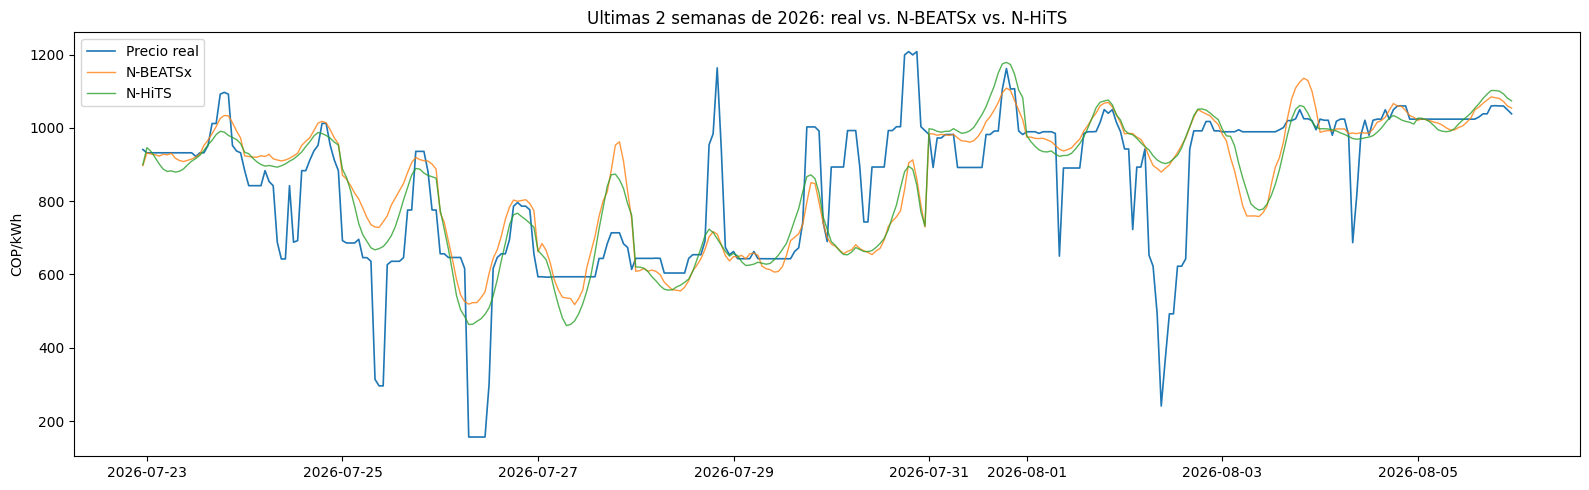

In [8]:
# --- Grafica: ultimas 2 semanas, real vs. ambos modelos ---
import matplotlib.pyplot as plt

ultimas_2_semanas = df_cv_precio[df_cv_precio["ds"] >= df_cv_precio["ds"].max() - pd.Timedelta(days=14)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ultimas_2_semanas["ds"], ultimas_2_semanas["y"], label="Precio real", linewidth=1.2)
ax.plot(ultimas_2_semanas["ds"], ultimas_2_semanas["NBEATSx"], label="N-BEATSx", linewidth=1, alpha=0.8)
ax.plot(ultimas_2_semanas["ds"], ultimas_2_semanas["NHITS"], label="N-HiTS", linewidth=1, alpha=0.8)
ax.set_title("Ultimas 2 semanas de 2026: real vs. N-BEATSx vs. N-HiTS")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion parcial

Ver metricas de las celdas de arriba. Consistente con Lago et al. (2021): si estos modelos no
superan a ARX+GARCH pese a ser arquitecturas mas modernas y con mas parametros, es la confirmacion
-- ahora con una cuarta y quinta familia de modelo, no solo tres -- de que la complejidad no es
lo que gana en este dominio especifico. Si alguno si supera a ARX+GARCH, seria el primer modelo
en toda la comparacion en hacerlo de forma clara, y ameritaria investigar por que (input_size,
mas exogenas, mas pasos de entrenamiento).

## Grid search: input_size (ventana de historia)

Mismo criterio que XGBoost y Prophet: se entrena SOLO con datos antes de 2025 y se valida contra
todo 2025 (365 ventanas diarias, sin tocar 2026 todavia). Se tunea `input_size` -- cuantas horas de
historia mira el modelo antes de pronosticar -- en 3, 1 y 2 semanas. Es el hiperparametro con mayor
impacto esperado: muy poca historia y el modelo no alcanza a ver el patron semanal completo; demasiada
y se vuelve mas lento sin necesariamente aportar mas señal (la serie ya tiene su propia periodicidad
capturada por las exogenas de calendario).

In [9]:
# --- Split de validacion: train < 2025, validar con las 365 ventanas diarias de 2025 ---
df_nf_gs = df_nf[df_nf["ds"] < "2026-01-01"].reset_index(drop=True)  # 2026 no se toca todavia
n_windows_gs = 365  # una ventana de 24h por dia de 2025

print(f"Filas disponibles para el grid search (train+valid, hasta fin de 2025): {len(df_nf_gs)}")
print(f"Ventanas de validacion (2025 completo): {n_windows_gs}")


Filas disponibles para el grid search (train+valid, hasta fin de 2025): 60625
Ventanas de validacion (2025 completo): 365


In [10]:
# --- Grid search de input_size para NBEATSx y NHITS ---
import time

valores_input_size = [72, 168, 336]  # 3 dias, 1 semana, 2 semanas
resultados_gs_dl = []

for ModeloClase, nombre_modelo in [(NBEATSx, "NBEATSx"), (NHITS, "NHITS")]:
    for input_size in valores_input_size:
        t0 = time.time()
        m = ModeloClase(h=horizonte, input_size=input_size, hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                         max_steps=MAX_STEPS, val_check_steps=100, random_seed=42, enable_progress_bar=False)
        nf_gs = NeuralForecast(models=[m], freq="h")
        cv_gs = nf_gs.cross_validation(df=df_nf_gs, n_windows=n_windows_gs, step_size=horizonte)

        mae = np.abs(cv_gs["y"].values - cv_gs[nombre_modelo].values).mean()
        resultados_gs_dl.append({"modelo": nombre_modelo, "input_size": input_size, "mae": mae,
                                  "segundos": time.time() - t0})
        print(f"{nombre_modelo:10s} input_size={input_size:4d} -> MAE {mae:6.2f}  ({time.time()-t0:.0f}s)")

df_gs_dl = pd.DataFrame(resultados_gs_dl)
df_gs_dl


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 4.8 M  | train
--------------------------------------------------------------
4.8 M     Trainable params
4.7 K     Non-trainable params
4.8 M     Total params
19.316    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=1000` reached.


...

`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


NHITS      input_size= 336 -> MAE  55.61  (339s)


,modelo,input_size,mae,segundos
0,NBEATSx,72,51.513069,177.659220
1,NBEATSx,168,50.220805,207.178907
2,NBEATSx,336,53.444054,370.070938
3,NHITS,72,51.999992,139.180285
4,NHITS,168,51.357998,199.294478
5,NHITS,336,55.606637,338.590414


In [11]:
# --- Persistencia en el mismo tramo de validacion (2025), como referencia ---
precio_lag24h_2025 = df_completo.set_index("fecha_hora").loc[
    df_completo[(df_completo["fecha_hora"] >= "2025-01-01") & (df_completo["fecha_hora"] < "2026-01-01")]["fecha_hora"],
    "precio_lag24h"
].values
precio_real_2025 = df_completo[(df_completo["fecha_hora"] >= "2025-01-01") & (df_completo["fecha_hora"] < "2026-01-01")]["precio_bolsa"].values
mae_persistencia_2025 = np.abs(precio_real_2025 - precio_lag24h_2025).mean()
print(f"Persistencia (valid. 2025): MAE {mae_persistencia_2025:.2f}\n")

mejor_nbeatsx = df_gs_dl[df_gs_dl["modelo"] == "NBEATSx"].sort_values("mae").iloc[0]
mejor_nhits = df_gs_dl[df_gs_dl["modelo"] == "NHITS"].sort_values("mae").iloc[0]
print(f"Mejor NBEATSx: input_size={int(mejor_nbeatsx['input_size'])} (MAE {mejor_nbeatsx['mae']:.2f})")
print(f"Mejor NHITS:   input_size={int(mejor_nhits['input_size'])} (MAE {mejor_nhits['mae']:.2f})")


Persistencia (valid. 2025): MAE 45.95

Mejor NBEATSx: input_size=168 (MAE 50.22)
Mejor NHITS:   input_size=168 (MAE 51.36)


In [12]:
# --- Reentrenar ambos ganadores sobre 2019-2025 completo, evaluar contra el holdout real de 2026 ---
modelo_nbeatsx_final = NBEATSx(h=horizonte, input_size=int(mejor_nbeatsx["input_size"]),
                                 hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                                 max_steps=MAX_STEPS, val_check_steps=100, random_seed=42, enable_progress_bar=False)
modelo_nhits_final = NHITS(h=horizonte, input_size=int(mejor_nhits["input_size"]),
                             hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                             max_steps=MAX_STEPS, val_check_steps=100, random_seed=42, enable_progress_bar=False)

nf_final = NeuralForecast(models=[modelo_nbeatsx_final, modelo_nhits_final], freq="h")

t0 = time.time()
df_cv_final = nf_final.cross_validation(df=df_nf, n_windows=n_windows, step_size=horizonte)
print(f"cross_validation final completo en {time.time()-t0:.1f}s")

df_cv_final_precio = df_cv_final.merge(
    df_completo[["fecha_hora", "precio_bolsa"]].rename(columns={"fecha_hora": "ds"}),
    on="ds", how="left"
)

calcular_metricas(df_cv_final_precio["y"], df_cv_final_precio["NBEATSx"], f"N-BEATSx (input={int(mejor_nbeatsx['input_size'])}h)")
calcular_metricas(df_cv_final_precio["y"], df_cv_final_precio["NHITS"], f"N-HiTS (input={int(mejor_nhits['input_size'])}h)")
calcular_metricas(df_cv_precio["y"], precio_lag24h_test, "Persistencia")
print("\nReferencia -- sin tunear (input=168h ambos): N-BEATSx MAE 56.11 | N-HiTS MAE 57.08")
print("Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")


Seed set to 42


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.4 M  | train
--------------------------------------------------------------
7.4 M     Trainable params
9.4 K     Non-trainable params
7.4 M     Total params
29.559    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


...


  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 5.9 M  | train
--------------------------------------------------------------
5.9 M     Trainable params
0         Non-trainable params
5.9 M     Total params
23.558    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


cross_validation final completo en 418.7s
N-BEATSx (input=168h)     MAE:    55.60  RMSE:    99.74  MAPE:  15.97%
N-HiTS (input=168h)       MAE:    57.45  RMSE:   100.28  MAPE:  16.61%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- sin tunear (input=168h ambos): N-BEATSx MAE 56.11 | N-HiTS MAE 57.08
Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%


In [13]:
# --- Diagnostico de regimen ONI, version final tuneada ---
for modelo_col, nombre in [("NBEATSx", "N-BEATSx"), ("NHITS", "N-HiTS")]:
    error_abs = np.abs(df_cv_final_precio["y"].values - df_cv_final_precio[modelo_col].values)
    alto = error_abs[oni_test >= mediana_oni]
    bajo = error_abs[oni_test < mediana_oni]
    print(f"{nombre:10s} -- ONI alto: {alto.mean():.2f}  |  ONI bajo: {bajo.mean():.2f}  |  razon: {alto.mean()/bajo.mean():.2f}x")

print("\nReferencia -- sin tunear: N-BEATSx 3.00x | N-HiTS 3.01x")
print("Referencia -- ARX+GARCH: 2.89x")


N-BEATSx   -- ONI alto: 83.16  |  ONI bajo: 28.05  |  razon: 2.96x
N-HiTS     -- ONI alto: 85.41  |  ONI bajo: 29.49  |  razon: 2.90x

Referencia -- sin tunear: N-BEATSx 3.00x | N-HiTS 3.01x
Referencia -- ARX+GARCH: 2.89x


## N-BEATSx mas pesado (misma arquitectura, mas capacidad) + ensamble de semillas

El grid search de `input_size` ya mostro que "mas contexto historico" (336h) perdia contra 168h --
pero eso es una sola dimension. Aqui se prueban dos formas distintas de agregarle capacidad al
MISMO N-BEATSx, sin cambiar de familia de arquitectura:

- **Mas pasos de entrenamiento** (`max_steps`): 1000 -> 2000, para revisar si el modelo actual
  estaba sub-entrenado.
- **Mas bloques por stack** (`n_blocks`): default `[1,1,1]` (un bloque por cada stack de
  identidad/tendencia/estacionalidad) -> `[2,2,2]`, literalmente el doble de capacidad de red.

Misma metodologia de siempre: validar con train<2025 / valid=2025, elegir el ganador, reentrenar
sobre 2019-2025 completo y evaluar contra el holdout real de 2026.

Despues, un **ensamble de 5 semillas** del modelo ganador -- la estrategia que el propio paper de
N-BEATS (Oreshkin et al., 2020) usa como su tecnica principal para mejorar precision (no arquitecturas
mas grandes, sino promediar varios modelos entrenados con distinta inicializacion).

In [14]:
# --- Configuraciones "mas pesadas" a probar, mismo split de validacion que el grid search de input_size ---
import time

configuraciones_peso = [
    {"nombre": "Base (ya conocido)", "max_steps": 1000, "n_blocks": [1, 1, 1], "mae_conocido": 51.48},
    {"nombre": "Mas pasos (2000)", "max_steps": 2000, "n_blocks": [1, 1, 1]},
    {"nombre": "Mas bloques (2,2,2)", "max_steps": 1000, "n_blocks": [2, 2, 2]},
]

resultados_peso = []
for cfg in configuraciones_peso:
    if "mae_conocido" in cfg:
        resultados_peso.append({"nombre": cfg["nombre"], "max_steps": cfg["max_steps"],
                                 "n_blocks": str(cfg["n_blocks"]), "mae": cfg["mae_conocido"], "segundos": None})
        print(f"{cfg['nombre']:25s} -> MAE {cfg['mae_conocido']:.2f}  (ya calculado en el grid search de input_size)")
        continue

    t0 = time.time()
    m = NBEATSx(h=horizonte, input_size=168, hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                 n_blocks=cfg["n_blocks"], max_steps=cfg["max_steps"], val_check_steps=100,
                 random_seed=42, enable_progress_bar=False)
    nf_p = NeuralForecast(models=[m], freq="h")
    cv_p = nf_p.cross_validation(df=df_nf_gs, n_windows=n_windows_gs, step_size=horizonte)

    mae = np.abs(cv_p["y"].values - cv_p["NBEATSx"].values).mean()
    dt = time.time() - t0
    resultados_peso.append({"nombre": cfg["nombre"], "max_steps": cfg["max_steps"],
                             "n_blocks": str(cfg["n_blocks"]), "mae": mae, "segundos": dt})
    print(f"{cfg['nombre']:25s} -> MAE {mae:.2f}  ({dt:.0f}s)")

df_peso = pd.DataFrame(resultados_peso)
df_peso


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.4 M  | train
--------------------------------------------------------------
7.4 M     Trainable params
9.4 K     Non-trainable params
7.4 M     Total params
29.559    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Base (ya conocido)        -> MAE 51.48  (ya calculado en el grid search de input_size)


...

`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Mas bloques (2,2,2)       -> MAE 56.48  (429s)


,nombre,max_steps,n_blocks,mae,segundos
0,Base (ya conocido),1000,"[1, 1, 1]",51.480000,NaN
1,Mas pasos (2000),2000,"[1, 1, 1]",55.113736,443.809472
2,"Mas bloques (2,2,2)",1000,"[2, 2, 2]",56.475945,428.789235


In [15]:
# --- Ganador de esta ronda, reentrenado sobre 2019-2025 completo, evaluado contra 2026 ---
ganador_peso = df_peso.sort_values("mae").iloc[0]
print(f"Ganador: {ganador_peso['nombre']} (MAE valid. 2025: {ganador_peso['mae']:.2f})")

max_steps_ganador = int(ganador_peso["max_steps"])
n_blocks_ganador = eval(ganador_peso["n_blocks"])

modelo_pesado_final = NBEATSx(h=horizonte, input_size=168, hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                                n_blocks=n_blocks_ganador, max_steps=max_steps_ganador, val_check_steps=100,
                                random_seed=42, enable_progress_bar=False)
nf_pesado = NeuralForecast(models=[modelo_pesado_final], freq="h")

t0 = time.time()
cv_pesado = nf_pesado.cross_validation(df=df_nf, n_windows=n_windows, step_size=horizonte)
print(f"cross_validation completo en {time.time()-t0:.0f}s")

cv_pesado_precio = cv_pesado.merge(
    df_completo[["fecha_hora", "precio_bolsa"]].rename(columns={"fecha_hora": "ds"}), on="ds", how="left"
)
calcular_metricas(cv_pesado_precio["y"], cv_pesado_precio["NBEATSx"], f"N-BEATSx pesado ({ganador_peso['nombre']})")
print("Referencia -- N-BEATSx base (input=168h, n_blocks=[1,1,1], max_steps=1000): MAE 56.11 | RMSE 100.92 | MAPE 15.93%")
print("Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")


Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.4 M  | train
--------------------------------------------------------------
7.4 M     Trainable params
9.4 K     Non-trainable params
7.4 M     Total params
29.559    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Ganador: Base (ya conocido) (MAE valid. 2025: 51.48)


`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


cross_validation completo en 209s
N-BEATSx pesado (Base (ya conocido)) MAE:    55.60  RMSE:    99.74  MAPE:  15.97%
Referencia -- N-BEATSx base (input=168h, n_blocks=[1,1,1], max_steps=1000): MAE 56.11 | RMSE 100.92 | MAPE 15.93%
Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%


### Ensamble de 5 semillas (misma configuracion ganadora, distinta inicializacion)

Se entrenan 5 modelos independientes (semillas 1-5) con la configuracion ganadora de arriba, cada
uno sobre 2019-2025 completo, y se promedian sus predicciones sobre 2026. Es la tecnica que el
propio paper de N-BEATS usa como su estrategia principal de mejora -- mas robusta que un solo
modelo mas grande, y mas barata de justificar (no es una arquitectura nueva, es "entrenar varias
veces y promediar").

In [16]:
# --- Ensamble: 5 modelos con la config ganadora, semillas distintas ---
predicciones_ensamble = []

for semilla in range(1, 6):
    t0 = time.time()
    m_ens = NBEATSx(h=horizonte, input_size=168, hist_exog_list=hist_exog, futr_exog_list=futr_exog,
                      n_blocks=n_blocks_ganador, max_steps=max_steps_ganador, val_check_steps=100,
                      random_seed=semilla, enable_progress_bar=False)
    nf_ens = NeuralForecast(models=[m_ens], freq="h")
    cv_ens = nf_ens.cross_validation(df=df_nf, n_windows=n_windows, step_size=horizonte)
    predicciones_ensamble.append(cv_ens["NBEATSx"].values)
    print(f"Semilla {semilla} lista ({time.time()-t0:.0f}s)")

prediccion_promedio = np.mean(predicciones_ensamble, axis=0)
y_real_ensamble = cv_ens["y"].values  # y_real es igual en todas las corridas (mismas fechas)

calcular_metricas(y_real_ensamble, prediccion_promedio, "N-BEATSx ensamble (5 semillas)")
print("Referencia -- N-BEATSx pesado (1 semilla):", f"MAE visto arriba")
print("Referencia -- N-BEATSx base: MAE 56.11 | RMSE 100.92 | MAPE 15.93%")
print("Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")


Seed set to 1


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 7.4 M  | train
--------------------------------------------------------------
7.4 M     Trainable params
9.4 K     Non-trainable params
7.4 M     Total params
29.559    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=1000` reached.


...

Semilla 4 lista (229s)


`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


Semilla 5 lista (226s)
N-BEATSx ensamble (5 semillas) MAE:    54.39  RMSE:    95.95  MAPE:  16.18%
Referencia -- N-BEATSx pesado (1 semilla): MAE visto arriba
Referencia -- N-BEATSx base: MAE 56.11 | RMSE 100.92 | MAPE 15.93%
Referencia -- ARX+GARCH(1,1): MAE 55.76 | RMSE 109.97 | MAPE 15.43%


In [17]:
# --- Diagnostico ONI del ensamble ---
error_abs_ens = np.abs(y_real_ensamble - prediccion_promedio)
alto_ens = error_abs_ens[oni_test >= mediana_oni]
bajo_ens = error_abs_ens[oni_test < mediana_oni]
print(f"N-BEATSx ensamble -- ONI alto: {alto_ens.mean():.2f}  |  ONI bajo: {bajo_ens.mean():.2f}  |  razon: {alto_ens.mean()/bajo_ens.mean():.2f}x")
print("Referencia -- N-BEATSx base: razon 3.00x  |  ARX+GARCH: razon 2.89x")


N-BEATSx ensamble -- ONI alto: 80.58  |  ONI bajo: 28.19  |  razon: 2.86x
Referencia -- N-BEATSx base: razon 3.00x  |  ARX+GARCH: razon 2.89x
